# Artificial Intellegence and Machine Learning

## A Program by Dhaarini AI-Tech Research Academy

### Assignment 2 : Binary Classification and Softmax.

### Classification

Classification is a supervised machine learning technique where the goal is to predict a category (label) based on input features.

The output is discrete (not continuous).

The model learns from labeled training data and predicts which class a new observation belongs to.

 In simple terms:
Classification answers the question — “Which group does this belong to?”

**Types of Classification**
1. Binary Classification

Predicts one of two possible classes.

**Examples:**

Spam vs Not Spam (Email filtering)

Disease vs No Disease (Medical diagnosis)

Loan Approved vs Rejected (Bank applications)

Promoted vs Not Promoted (Employee dataset)

**Example Output:**
0 or 1, Yes or No, Positive or Negative


### Dataset Description


In this example, we will be using a bank loan approval dataset.

The variable descriptions are as follows:

Input Feature: **bold text**

CreditScore – A numerical value that represents a customer’s creditworthiness. A higher credit score indicates that the customer is financially reliable, while a lower score indicates higher financial risk.

Additional Features (present in raw dataset, if any):

1. loan_id

Unique identifier for each loan application.

2. no_of_dependents

Number of family members financially dependent on the applicant.

3. education

Education level of the applicant.
Values may include:

Graduate

Not Graduate

4. self_employed

Indicates whether the applicant is self-employed.
Values: Yes / No

5. income_annum

Applicant’s annual income.

6. loan_amount

Total loan amount requested by the applicant.

7. cibil_score

Applicant’s CIBIL credit score (creditworthiness indicator).

8. loan_status (Target Feature)

Final decision of the bank for the loan application.
Values:

Approved

Rejected

Note: These features may exist in the raw dataset but are not used in the current logistic regression model because the objective is to predict loan approval using only the credit score.

Target Feature:

LoanApproved – Loan approval status of the customer

0 = Not Approved

1 = Approved

Problem Statement

To predict whether a customer’s loan application will be approved or not approved based on their credit score.

In [78]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [79]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,cibil_score,loan_status
0,1,2,Graduate,No,9600000,29900000,778,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,417,Rejected
2,3,3,Graduate,No,9100000,29700000,506,Rejected
3,4,3,Graduate,No,8200000,30700000,467,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,382,Rejected


In [80]:
print(df.columns)
X = df[[' cibil_score']]
y = df[' loan_status']

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' cibil_score', ' loan_status'],
      dtype='object')


In [81]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [82]:
X_train

,cibil_score
2488,547
3703,378
3347,601
3487,690
3957,374
...,...
1033,752
3264,363
1653,684
2607,786


In [83]:
y_train

2488     Rejected
3703     Rejected
3347     Approved
3487     Approved
3957     Rejected
          ...    
1033     Approved
3264     Rejected
1653     Approved
2607     Approved
2732     Approved
Name:  loan_status, Length: 3415, dtype: object

In [84]:
X_test

,cibil_score
1972,673
528,559
3540,551
87,402
1621,362
...,...
1505,433
2423,436
489,492
2653,799


In [85]:
y_test

1972     Approved
528      Approved
3540     Approved
87       Rejected
1621     Rejected
          ...    
1505     Approved
2423     Rejected
489      Rejected
2653     Approved
3881     Rejected
Name:  loan_status, Length: 854, dtype: object

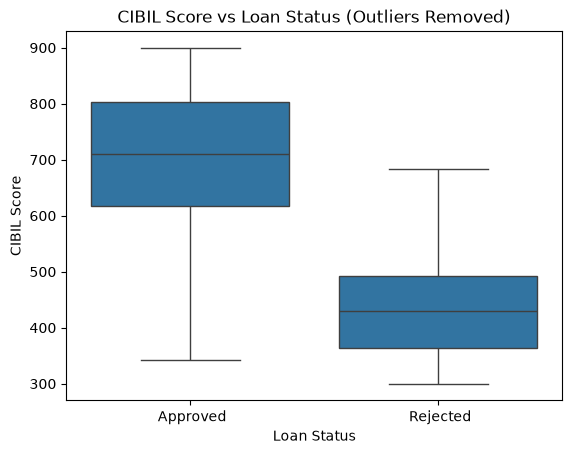

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(
    x=' loan_status',
    y=' cibil_score',
    data=df,
    showfliers=False  # removes outliers from the figure
)
plt.title('CIBIL Score vs Loan Status (Outliers Removed)')
plt.xlabel('Loan Status')
plt.ylabel('CIBIL Score')
plt.show()

In [87]:
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [88]:
y_pred = model.predict(X_test)

In [89]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9180327868852459

Confusion Matrix:
 [[488  35]
 [ 35 296]]

Classification Report:
               precision    recall  f1-score   support

    Approved       0.93      0.93      0.93       523
    Rejected       0.89      0.89      0.89       331

    accuracy                           0.92       854
   macro avg       0.91      0.91      0.91       854
weighted avg       0.92      0.92      0.92       854



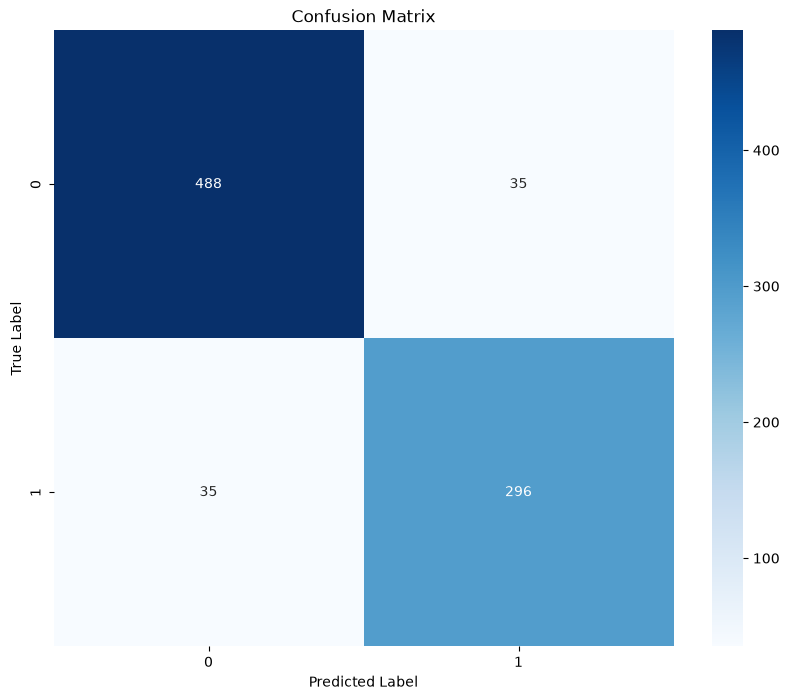

In [90]:
# Using Matplotlib
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [91]:
# Predict new instance
new_credit_score = [[550]]
prediction = model.predict(new_credit_score)
print("\nPrediction for credit score:", prediction)


Prediction for credit score: [' Approved']


/home/arshadruk/Programs/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


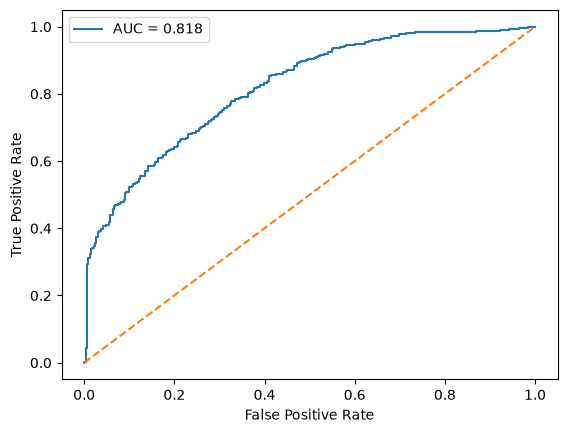

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Load data
df = pd.read_csv("loan_approval_dataset.csv")
df.columns = df.columns.str.strip()

# Binary target encoding
y = df['loan_status'].str.strip().map({'Rejected': 0, 'Approved': 1})
X = df[['cibil_score', 'income_annum']]

# Drop missing values
mask = y.notna()
X = X[mask]
y = y[mask]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0,
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ROC & AUC
y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

The diagram above illustrates:

 The Blue dotted line is the ROC curve.

 The region beneath the orange dotted line is known as AUROC.

 The reference line is indicated by the Red dotted line.

####Softmax Function

Multinomial Regression is a type of classification algorithm used when the target variable has more than two categories.
 Another name for it is **multinomial logistic regression**.

**Examples:**

Classifying fruit: Apple / Banana / Orange


Weather type: Sunny / Rainy / Cloudy

Education level: High school / Bachelor / Master / PhD

**Example Output:**
0, 1, 2, 3...

Applying Softmax Regression to the "loan_approval_dataset (1).csv" dataset.

In [93]:
# Features & Target
X = df[['cibil_score','income_annum']]
y = df['loan_status']

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [95]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [96]:
# Create multinomial logistic regression
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [97]:
# Predictions
y_pred = model.predict(X_test)


In [98]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9241573033707865

Confusion Matrix:
 [[622  37]
 [ 44 365]]

Classification Report:
               precision    recall  f1-score   support

    Approved       0.93      0.94      0.94       659
    Rejected       0.91      0.89      0.90       409

    accuracy                           0.92      1068
   macro avg       0.92      0.92      0.92      1068
weighted avg       0.92      0.92      0.92      1068



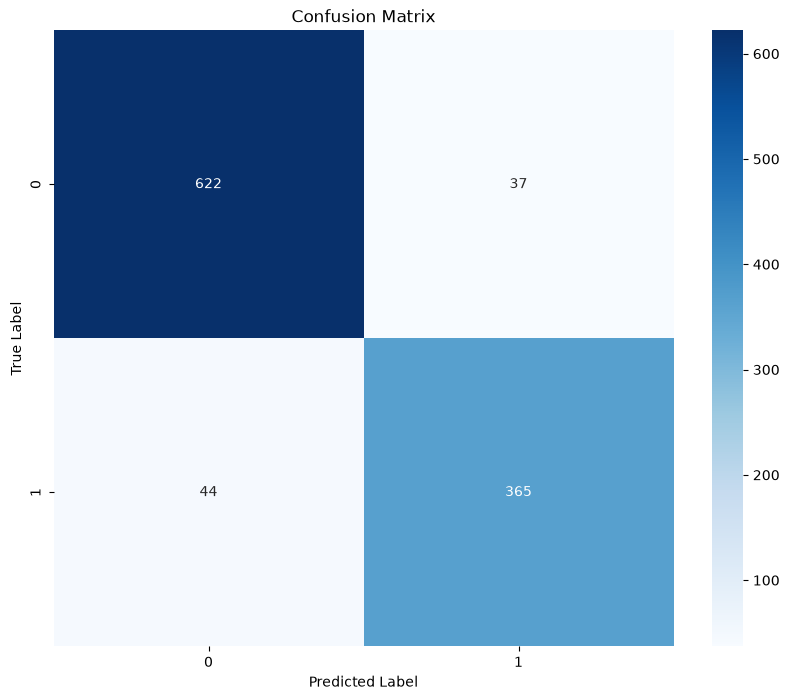

In [99]:
# Using Matplotlib
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [100]:
# Predict for new credit score and income
# Example: credit score of 700 and income of 5000000
new_instance = [[700, 5000000]]
# Scale the new instance using the same scaler fitted on the training data
new_instance_scaled = sc.transform(new_instance)
prediction = model.predict(new_instance_scaled)
print(f"\nPrediction for cibil score 700 and income 5000000: {prediction[0]}")


Prediction for cibil score 700 and income 5000000:  Approved


/home/arshadruk/Programs/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [101]:
import pandas as pd

# Load dataset
df = pd.read_csv("loan_approval_dataset.csv")
df.columns = df.columns.str.strip()

# Create a new 3-class target
def loan_status_multiclass(cibil):
    if cibil >= 700:
        return "Accepted"
    elif cibil >= 550:
        return "Pending"
    else:
        return "Rejected"

df["loan_status_multiclass"] = df["cibil_score"].apply(loan_status_multiclass)

# Check class distribution
print(df["loan_status_multiclass"].value_counts())

df.head()


loan_status_multiclass
Rejected    1785
Accepted    1430
Pending     1054
Name: count, dtype: int64


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,cibil_score,loan_status,loan_status_multiclass
0,1,2,Graduate,No,9600000,29900000,778,Approved,Accepted
1,2,0,Not Graduate,Yes,4100000,12200000,417,Rejected,Rejected
2,3,3,Graduate,No,9100000,29700000,506,Rejected,Rejected
3,4,3,Graduate,No,8200000,30700000,467,Rejected,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,382,Rejected,Rejected


In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[['cibil_score', 'income_annum']]
y = df['loan_status_multiclass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i